# Exemplo: Temperaturas ao Longo do Dia

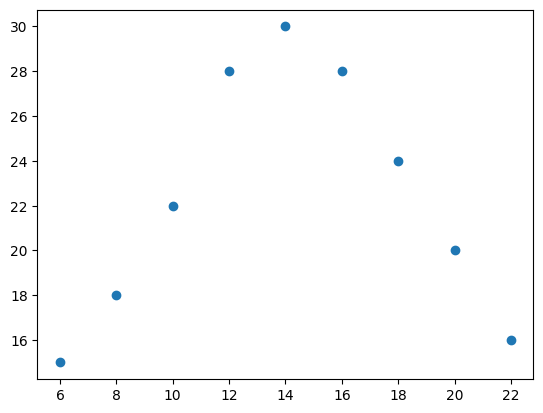

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Dados observados: temperatura (°C) a cada 2 horas
horas = np.array([6, 8, 10, 12, 14, 16, 18, 20, 22])
temperatura = np.array([15, 18, 22, 28, 30, 28, 24, 20, 16])


X = horas
y = temperatura


plt.scatter(X, y)



In [2]:

## PRÉ-TREINO

p_features = PolynomialFeatures(degree=2)
X_p_features = p_features.fit_transform(X.reshape(-1, 1))
X_p_features


array([[  1.,   6.,  36.],
       [  1.,   8.,  64.],
       [  1.,  10., 100.],
       [  1.,  12., 144.],
       [  1.,  14., 196.],
       [  1.,  16., 256.],
       [  1.,  18., 324.],
       [  1.,  20., 400.],
       [  1.,  22., 484.]])

In [3]:
## TREINAMENTO DO MODELO

regressao = LinearRegression()
regressao.fit(X_p_features, y)

print(f"a = {regressao.coef_}, b = {regressao.intercept_}")


a = [ 0.          6.07121212 -0.21266234], b = -15.310822510822813


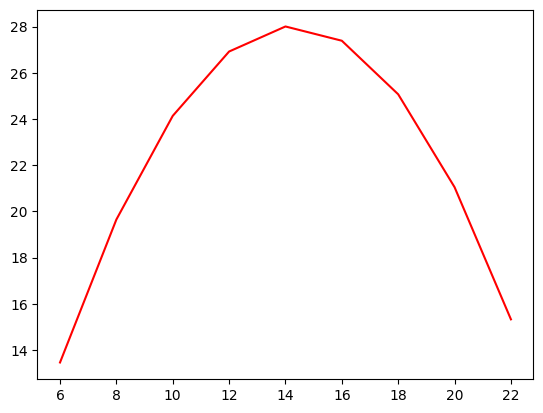

In [4]:
## PREDIÇÕES COM O MODELO POLINOMIAL AJUSTADO

# usamos os dados observados (os mesmos usados para gerar os dados)

## vamos transformar os valores aleatórios de X (X_aleat)
X_polinomiais = p_features.transform(X.reshape(-1, 1)) # transforma dados em PolinomialFeatures

# prevemos os valores de y correspondentes aos X_polinomiais 
y_predito = regressao.predict(X_polinomiais)


## PLOTAGEM DA CURVA POLINOMIAL AJUSTADA
# plotamos o modelo
plt.plot(X, y_predito, color="r")


tudo junto

a = [ 0.          6.07121212 -0.21266234], b = -15.310822510822813


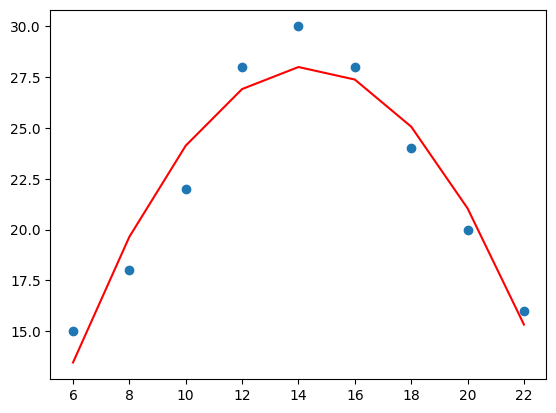

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Dados observados: temperatura (°C) a cada 2 horas
horas = np.array([6, 8, 10, 12, 14, 16, 18, 20, 22])
temperatura = np.array([15, 18, 22, 28, 30, 28, 24, 20, 16])


X = horas
y = temperatura


plt.scatter(X, y)


## PRÉ-TREINO

p_features = PolynomialFeatures(degree=2)
X_p_features = p_features.fit_transform(X.reshape(-1, 1))
X_p_features


## TREINAMENTO DO MODELO

regressao = LinearRegression()
regressao.fit(X_p_features, y)

print(f"a = {regressao.coef_}, b = {regressao.intercept_}")


## PREDIÇÕES COM O MODELO POLINOMIAL AJUSTADO

# usamos os dados observados (os mesmos usados para gerar os dados)

## vamos transformar os valores aleatórios de X (X_aleat)
X_polinomiais = p_features.transform(X.reshape(-1, 1)) # transforma dados em PolinomialFeatures

# prevemos os valores de y correspondentes aos X_polinomiais 
y_predito = regressao.predict(X_polinomiais)


## PLOTAGEM DA CURVA POLINOMIAL AJUSTADA
# plotamos o modelo
plt.plot(X, y_predito, color="r")


Qualidade do modelo

In [6]:
regressao.score(X_polinomiais, y)

0.9267901497409693

### Previsão de um ponto

As temperaturas para 13h e 15h não foram observadas. Para fazer uma predição com esses valores, criamos um array contendo cada valor em um array (um array que contém arrays).

In [ ]:
## vamos transformar os valores de X
X_ponto = p_features.transform([[13], [15]])

# prevemos os valores de y correspondentes aos X_polinomiais 
y_predito = regressao.predict(X_ponto)
y_predito   # aprox. 27,7 e 27,9  

array([27.675     , 27.90833333])